Download & Ekstraksi Dataset MNIST

In [ ]:
! pip install kaggle

In [ ]:
kaggle = '/content/kaggle.json '

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.80GB/s]


In [ ]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "datasets"
os.makedirs(extract_folder, exist_ok= True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [ ]:
data_0 = os.listdir('/content/datasets/0')
data_1 = os.listdir('/content/datasets/1')
data_2 = os.listdir('/content/datasets/2')
data_3 = os.listdir('/content/datasets/3')
data_4 = os.listdir('/content/datasets/4')
data_5 = os.listdir('/content/datasets/5')
data_6 = os.listdir('/content/datasets/6')
data_7 = os.listdir('/content/datasets/7')
data_8 = os.listdir('/content/datasets/8')
data_9 = os.listdir('/content/datasets/9')


In [ ]:
len(data_0)

2236

1. Load Gambar + Label

In [ ]:
import cv2
import numpy as np

X = []
y = []

base_path = "/content/datasets"

for label in range(10):
    folder_path = os.path.join(base_path, str(label))
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))  # samakan ukuran MNIST

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)


(21555, 28, 28)
(21555,)


2. Visualisasi Data

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

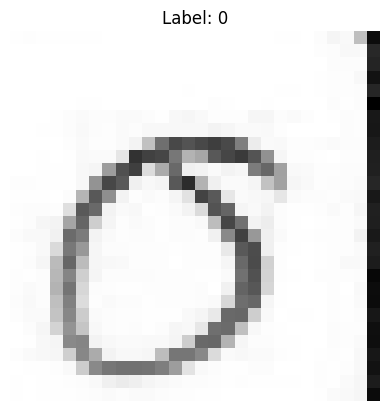

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')


3.  Preprocessing

In [ ]:
# a. Flatten Image
X = X.reshape(X.shape[0], 28*28)


In [ ]:
# b. Normalisasi
X = X / 255.0


In [ ]:
# c. One-Hot Encoding Label
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=10)


4. Split Data Train & Test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


5. Bangun Model MLP (ANN)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

7. Training + Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1051 - loss: 2.4107 - val_accuracy: 0.1087 - val_loss: 2.3025
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0981 - loss: 2.3027 - val_accuracy: 0.0928 - val_loss: 2.3027
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1057 - loss: 2.3020 - val_accuracy: 0.1050 - val_loss: 2.3030
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1105 - loss: 2.3014 - val_accuracy: 0.1050 - val_loss: 2.3031
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1083 - loss: 2.3014 - val_accuracy: 0.1050 - val_loss: 2.3032
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1063 - loss: 2.3018 - val_accuracy: 0.1050 - val_loss: 2.3034


8. Evaluasi Model

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1061 - loss: 2.3022
Test Accuracy: 0.10809557139873505


9. Visualisasi Accuracy & Loss

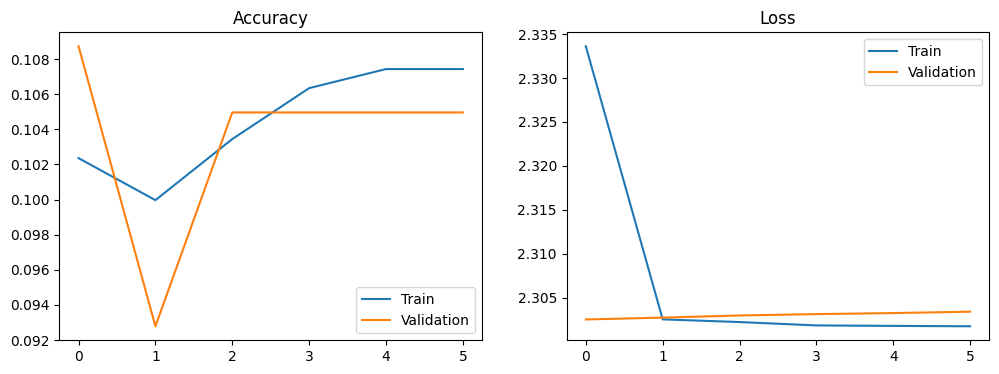

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()
